In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from mlxtend.plotting import plot_decision_regions


In [3]:
dataset = pd.read_csv("../datasets/subscription_dataset.csv")
dataset.head()


,Age,EstimatedSalary,Purchased
0,56,40342,0
1,46,121308,1
2,32,121081,1
3,25,104045,1
4,38,49698,0


In [4]:
X = dataset.iloc[:, :-1].values
y = dataset["Purchased"].values


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [6]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


In [8]:
class PolyLogisticClassifier:
    def __init__(self, degree):
        self.degree = degree
        self.poly = PolynomialFeatures(degree=degree)
        self.model = LogisticRegression(max_iter=1000)

    def fit(self, X, y):
        X_poly = self.poly.fit_transform(X)
        self.model.fit(X_poly, y)
        return self

    def predict(self, X):
        X_poly = self.poly.transform(X)
        return self.model.predict(X_poly)


In [9]:
def train_and_plot(degree):
    clf = PolyLogisticClassifier(degree)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"\nPolynomial Degree: {degree}")
    print(f"Test Accuracy: {acc*100:.2f}%")

    plot_decision_regions(
        X_train,
        y_train,
        clf=clf,
        legend=2
    )

    plt.title(f"Decision Boundary (Degree = {degree})")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()



Polynomial Degree: 1
Test Accuracy: 82.50%


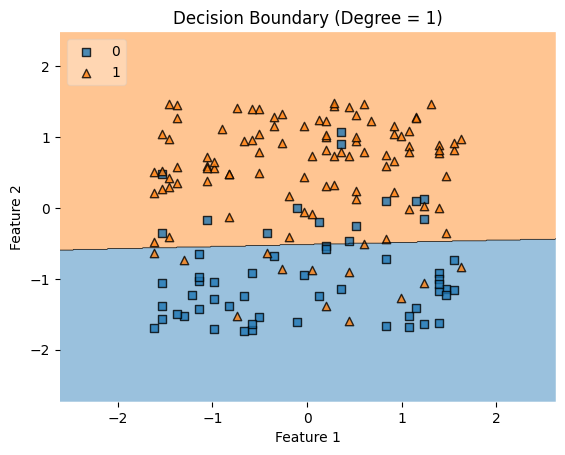

In [10]:
train_and_plot(degree=1)



Polynomial Degree: 3
Test Accuracy: 77.50%


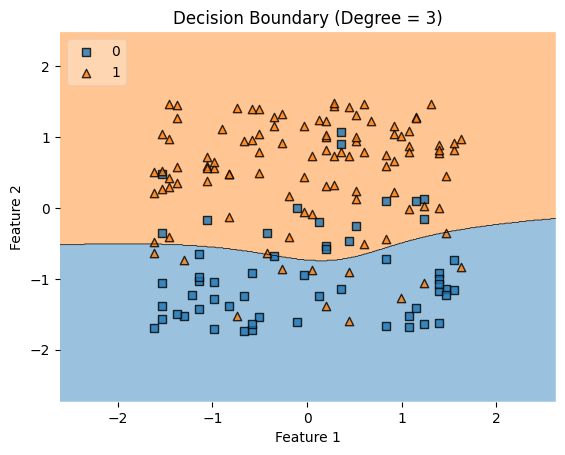

In [11]:
train_and_plot(degree=3)



Polynomial Degree: 10
Test Accuracy: 72.50%


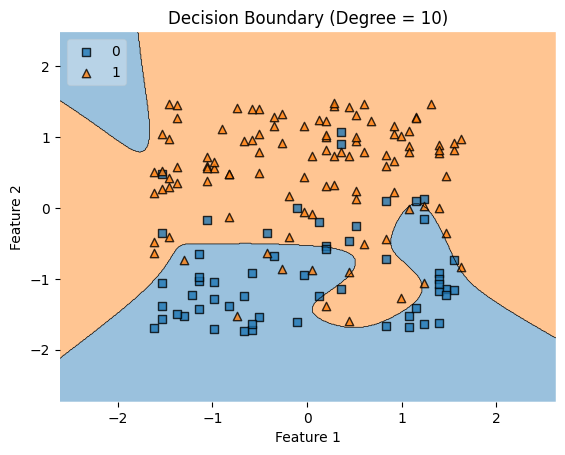

In [12]:
train_and_plot(degree=10)


Epoch 01 | Loss: 56.0000 | Weight w: 1.8667
Epoch 02 | Loss: 0.2489 | Weight w: 1.9911
Epoch 03 | Loss: 0.0011 | Weight w: 1.9994
Epoch 04 | Loss: 0.0000 | Weight w: 2.0000
Epoch 05 | Loss: 0.0000 | Weight w: 2.0000
Epoch 06 | Loss: 0.0000 | Weight w: 2.0000
Epoch 07 | Loss: 0.0000 | Weight w: 2.0000
Epoch 08 | Loss: 0.0000 | Weight w: 2.0000
Epoch 09 | Loss: 0.0000 | Weight w: 2.0000
Epoch 10 | Loss: 0.0000 | Weight w: 2.0000
Epoch 11 | Loss: 0.0000 | Weight w: 2.0000
Epoch 12 | Loss: 0.0000 | Weight w: 2.0000
Epoch 13 | Loss: 0.0000 | Weight w: 2.0000
Epoch 14 | Loss: 0.0000 | Weight w: 2.0000
Epoch 15 | Loss: 0.0000 | Weight w: 2.0000
Epoch 16 | Loss: 0.0000 | Weight w: 2.0000
Epoch 17 | Loss: 0.0000 | Weight w: 2.0000
Epoch 18 | Loss: 0.0000 | Weight w: 2.0000
Epoch 19 | Loss: 0.0000 | Weight w: 2.0000
Epoch 20 | Loss: 0.0000 | Weight w: 2.0000


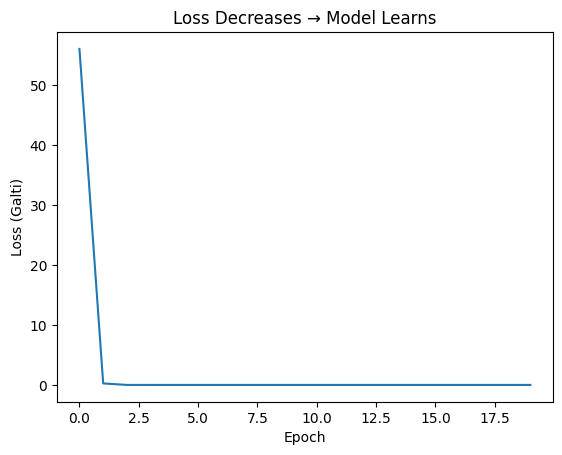

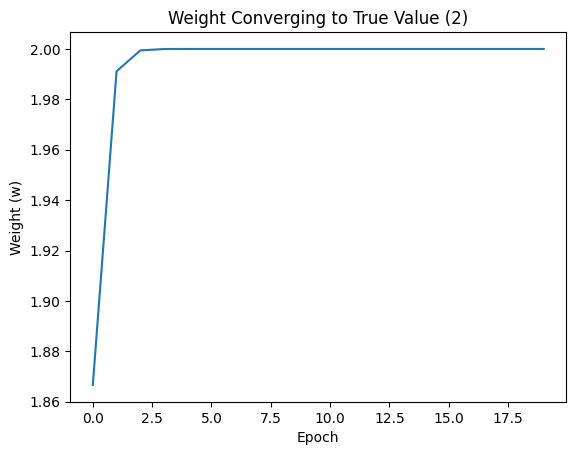

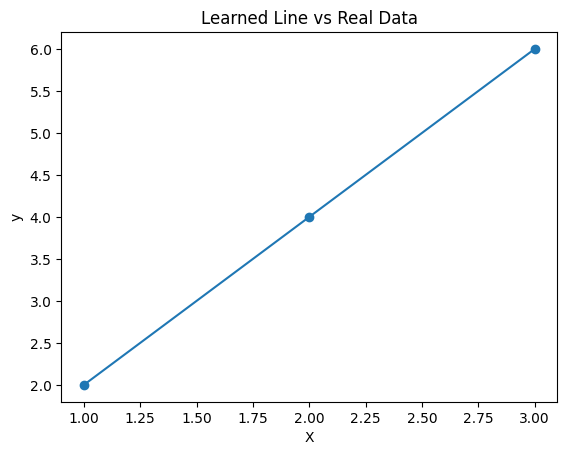


✅ Final Learned Model:
y = 2.0 * x


In [5]:
# =========================================================
# GRADIENT DESCENT FROM SCRATCH (FULL INTUITION)
# =========================================================
# Model        = formula
# Loss         = galti
# Gradient     = direction
# LearningRate = speed
# Training     = repeated correction
# =========================================================

import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1️⃣ DATA (Ground Truth)
# ---------------------------------------------------------
# Real relationship: y = 2x
X = [1, 2, 3]
y = [2, 4, 6]

# ---------------------------------------------------------
# 2️⃣ MODEL (Formula)
# ---------------------------------------------------------
# y_pred = w * x
w = 0.0   # wrong initial guess (brain empty)

# ---------------------------------------------------------
# 3️⃣ TRAINING SETTINGS
# ---------------------------------------------------------
learning_rate = 0.1   # speed of learning
epochs = 20

loss_history = []
weight_history = []

# ---------------------------------------------------------
# 4️⃣ TRAINING LOOP (Repeated Correction)
# ---------------------------------------------------------
for epoch in range(epochs):

    total_loss = 0
    gradient = 0

    # ---- Step A: Prediction + Loss + Gradient ----
    for xi, yi in zip(X, y):

        y_pred = w * xi              # model prediction
        error = yi - y_pred          # galti (loss ka base)

        total_loss += error ** 2     # squared loss
        gradient += -2 * xi * error  # direction

    gradient = gradient / len(X)     # average gradient

    # ---- Step B: Update (Learning happens here) ----
    w = w - learning_rate * gradient

    # ---- Store history ----
    loss_history.append(total_loss)
    weight_history.append(w)

    print(f"Epoch {epoch+1:02d} | Loss: {total_loss:.4f} | Weight w: {w:.4f}")

# ---------------------------------------------------------
# 5️⃣ GRAPH 1: LOSS vs EPOCHS
# ---------------------------------------------------------
plt.figure()
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss (Galti)")
plt.title("Loss Decreases → Model Learns")
plt.show()

# ---------------------------------------------------------
# 6️⃣ GRAPH 2: WEIGHT vs EPOCHS
# ---------------------------------------------------------
plt.figure()
plt.plot(weight_history)
plt.xlabel("Epoch")
plt.ylabel("Weight (w)")
plt.title("Weight Converging to True Value (2)")
plt.show()

# ---------------------------------------------------------
# 7️⃣ FINAL MODEL VISUALIZATION
# ---------------------------------------------------------
predicted_y = [w * xi for xi in X]

plt.figure()
plt.scatter(X, y)
plt.plot(X, predicted_y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Learned Line vs Real Data")
plt.show()

print("\n✅ Final Learned Model:")
print("y =", round(w, 3), "* x")


[Batch] Epoch 1, Loss 56.0000, w 1.8667
[Batch] Epoch 2, Loss 0.2489, w 1.9911
[Batch] Epoch 3, Loss 0.0011, w 1.9994
[Batch] Epoch 4, Loss 0.0000, w 2.0000
[Batch] Epoch 5, Loss 0.0000, w 2.0000
[Batch] Epoch 6, Loss 0.0000, w 2.0000
[Batch] Epoch 7, Loss 0.0000, w 2.0000
[Batch] Epoch 8, Loss 0.0000, w 2.0000
[Batch] Epoch 9, Loss 0.0000, w 2.0000
[Batch] Epoch 10, Loss 0.0000, w 2.0000
[Batch] Epoch 11, Loss 0.0000, w 2.0000
[Batch] Epoch 12, Loss 0.0000, w 2.0000
[Batch] Epoch 13, Loss 0.0000, w 2.0000
[Batch] Epoch 14, Loss 0.0000, w 2.0000
[Batch] Epoch 15, Loss 0.0000, w 2.0000
[Batch] Epoch 16, Loss 0.0000, w 2.0000
[Batch] Epoch 17, Loss 0.0000, w 2.0000
[Batch] Epoch 18, Loss 0.0000, w 2.0000
[Batch] Epoch 19, Loss 0.0000, w 2.0000
[Batch] Epoch 20, Loss 0.0000, w 2.0000


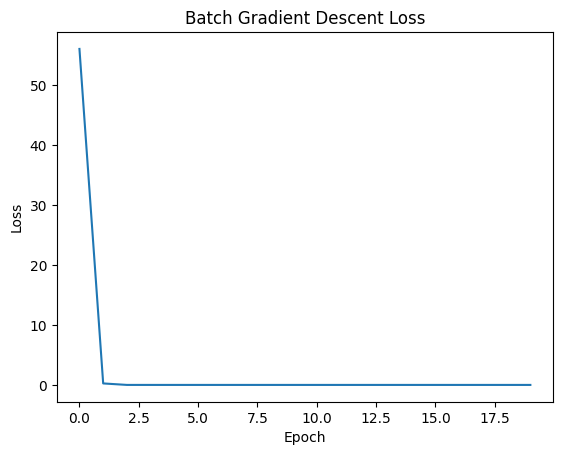

In [16]:
import matplotlib.pyplot as plt

w = 0.0
lr = 0.1
epochs = 20
loss_history = []

for epoch in range(epochs):
    total_loss = 0
    grad = 0

    for xi, yi in zip(X, y):
        y_pred = w * xi
        error = yi - y_pred
        total_loss += error**2
        grad += -2 * xi * error

    grad = grad / len(X)      # full batch average
    w = w - lr * grad

    loss_history.append(total_loss)
    print(f"[Batch] Epoch {epoch+1}, Loss {total_loss:.4f}, w {w:.4f}")

plt.plot(loss_history)
plt.title("Batch Gradient Descent Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


[SGD] Epoch 1, Loss 15.1616, w 2.2560
[SGD] Epoch 2, Loss 0.2484, w 1.9672
[SGD] Epoch 3, Loss 0.0041, w 2.0042
[SGD] Epoch 4, Loss 0.0001, w 1.9995
[SGD] Epoch 5, Loss 0.0000, w 2.0001
[SGD] Epoch 6, Loss 0.0000, w 2.0000
[SGD] Epoch 7, Loss 0.0000, w 2.0000
[SGD] Epoch 8, Loss 0.0000, w 2.0000
[SGD] Epoch 9, Loss 0.0000, w 2.0000
[SGD] Epoch 10, Loss 0.0000, w 2.0000
[SGD] Epoch 11, Loss 0.0000, w 2.0000
[SGD] Epoch 12, Loss 0.0000, w 2.0000
[SGD] Epoch 13, Loss 0.0000, w 2.0000
[SGD] Epoch 14, Loss 0.0000, w 2.0000
[SGD] Epoch 15, Loss 0.0000, w 2.0000
[SGD] Epoch 16, Loss 0.0000, w 2.0000
[SGD] Epoch 17, Loss 0.0000, w 2.0000
[SGD] Epoch 18, Loss 0.0000, w 2.0000
[SGD] Epoch 19, Loss 0.0000, w 2.0000
[SGD] Epoch 20, Loss 0.0000, w 2.0000


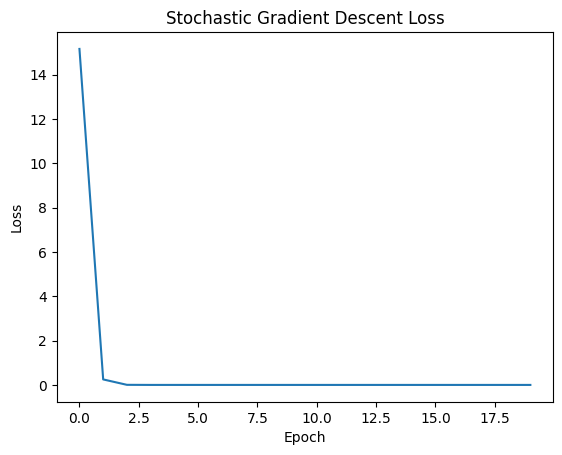

In [10]:
w = 0.0
lr = 0.1
epochs = 20
loss_history = []

for epoch in range(epochs):
    total_loss = 0

    for xi, yi in zip(X, y):
        y_pred = w * xi
        error = yi - y_pred
        loss = error**2

        grad = -2 * xi * error
        w = w - lr * grad     # update immediately

        total_loss += loss

    loss_history.append(total_loss)
    print(f"[SGD] Epoch {epoch+1}, Loss {total_loss:.4f}, w {w:.4f}")

plt.plot(loss_history)
plt.title("Stochastic Gradient Descent Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


[MiniBatch] Epoch 1, Loss 29.0000, w 2.8000
[MiniBatch] Epoch 2, Loss 4.6400, w 1.6800
[MiniBatch] Epoch 3, Loss 0.7424, w 2.1280
[MiniBatch] Epoch 4, Loss 0.1188, w 1.9488
[MiniBatch] Epoch 5, Loss 0.0190, w 2.0205
[MiniBatch] Epoch 6, Loss 0.0030, w 1.9918
[MiniBatch] Epoch 7, Loss 0.0005, w 2.0033
[MiniBatch] Epoch 8, Loss 0.0001, w 1.9987
[MiniBatch] Epoch 9, Loss 0.0000, w 2.0005
[MiniBatch] Epoch 10, Loss 0.0000, w 1.9998
[MiniBatch] Epoch 11, Loss 0.0000, w 2.0001
[MiniBatch] Epoch 12, Loss 0.0000, w 2.0000
[MiniBatch] Epoch 13, Loss 0.0000, w 2.0000
[MiniBatch] Epoch 14, Loss 0.0000, w 2.0000
[MiniBatch] Epoch 15, Loss 0.0000, w 2.0000
[MiniBatch] Epoch 16, Loss 0.0000, w 2.0000
[MiniBatch] Epoch 17, Loss 0.0000, w 2.0000
[MiniBatch] Epoch 18, Loss 0.0000, w 2.0000
[MiniBatch] Epoch 19, Loss 0.0000, w 2.0000
[MiniBatch] Epoch 20, Loss 0.0000, w 2.0000


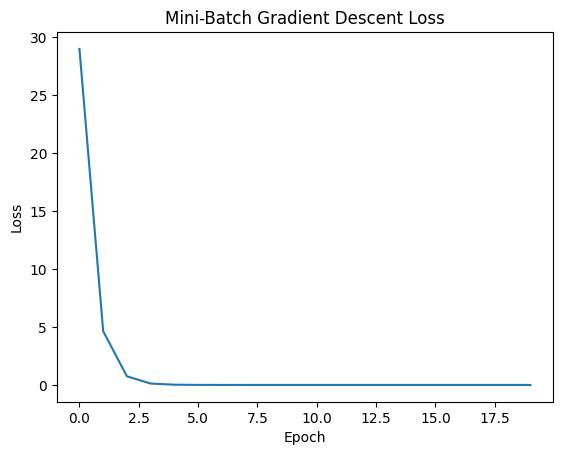

In [11]:
w = 0.0
lr = 0.1
epochs = 20
batch_size = 2
loss_history = []

for epoch in range(epochs):
    total_loss = 0

    for i in range(0, len(X), batch_size):
        batch_X = X[i:i+batch_size]
        batch_y = y[i:i+batch_size]

        grad = 0
        for xi, yi in zip(batch_X, batch_y):
            y_pred = w * xi
            error = yi - y_pred
            total_loss += error**2
            grad += -2 * xi * error

        grad = grad / len(batch_X)
        w = w - lr * grad

    loss_history.append(total_loss)
    print(f"[MiniBatch] Epoch {epoch+1}, Loss {total_loss:.4f}, w {w:.4f}")

plt.plot(loss_history)
plt.title("Mini-Batch Gradient Descent Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


First 5 rows of dataset:
   Age  EstimatedSalary  Purchased
0   56            40342          0
1   46           121308          1
2   32           121081          1
3   25           104045          1
4   38            49698          0

Feature types:
Age                int64
EstimatedSalary    int64
dtype: object

Training samples: 160, Test samples: 40

--- Training Polynomial Logistic Regression (Degree=1) ---
Test Accuracy: 82.50%


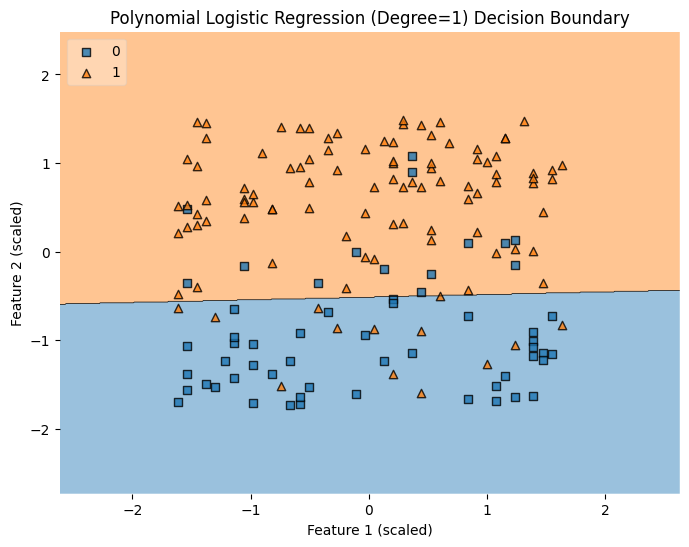


Learned Coefficients:
Feature 1: -0.0581
Feature 2: 1.9366

--- Training Polynomial Logistic Regression (Degree=3) ---
Test Accuracy: 77.50%


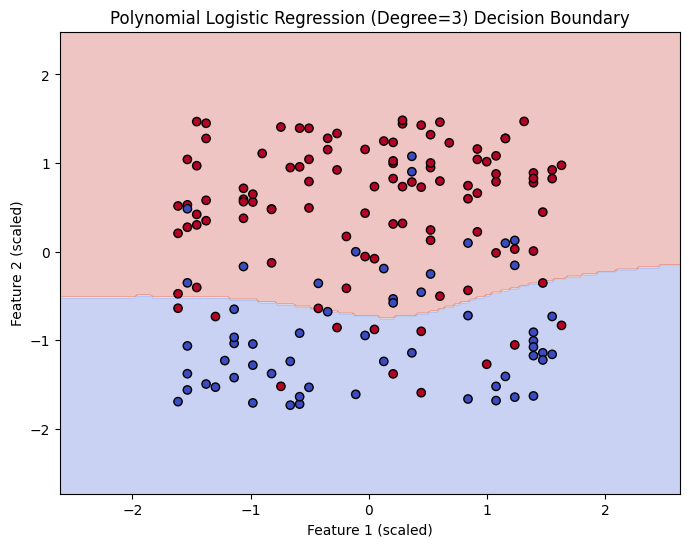


Learned Coefficients:
Feature 1: -0.1463
Feature 2: 1.0438
Feature 3: 0.2423
Feature 4: -0.1838
Feature 5: 0.4222
Feature 6: -0.0599
Feature 7: 0.8143
Feature 8: 0.2256
Feature 9: 0.3421

--- Training Polynomial Logistic Regression (Degree=10) ---
Test Accuracy: 72.50%


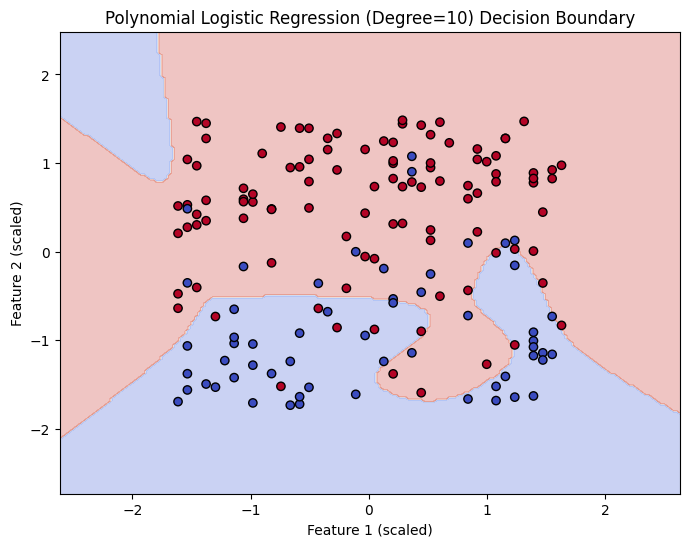


Learned Coefficients:
Feature 1: -0.1873
Feature 2: 1.3972
Feature 3: 0.1724
Feature 4: -0.3878
Feature 5: -0.0203
Feature 6: 0.0181
Feature 7: 0.4090
Feature 8: 0.0715
Feature 9: 0.2082
Feature 10: 0.0535
Feature 11: -0.2805
Feature 12: 0.4791
Feature 13: -0.4394
Feature 14: -0.2864
Feature 15: -0.2860
Feature 16: 0.1485
Feature 17: 0.2919
Feature 18: -0.0031
Feature 19: 0.1021
Feature 20: -0.0599
Feature 21: -0.1754
Feature 22: -0.0469
Feature 23: 0.4478
Feature 24: -0.1205
Feature 25: 0.4200
Feature 26: -0.4563
Feature 27: -0.0758
Feature 28: -0.4373
Feature 29: 0.0218
Feature 30: 0.1383
Feature 31: 0.0221
Feature 32: 0.3100
Feature 33: -0.0600
Feature 34: -0.0579
Feature 35: -0.2559
Feature 36: -0.4074
Feature 37: 0.2795
Feature 38: 0.2585
Feature 39: -0.0018
Feature 40: 0.2248
Feature 41: -0.1066
Feature 42: 0.3827
Feature 43: -0.1508
Feature 44: 0.4800
Feature 45: 0.3449
Feature 46: 0.2080
Feature 47: -0.1238
Feature 48: -0.0482
Feature 49: 0.4190
Feature 50: 0.5657
Feature 51: 

In [23]:
# =========================================================
# MACHINE LEARNING PIPELINES & COLUMN TRANSFORMER - UPDATED
# =========================================================
# ✅ Goal:
# Feature-specific preprocessing + polynomial logistic regression + visualization
# ✅ Fixes:
# 1. All numeric features scaled (no categorical encoding needed)
# 2. Decision boundary works for both degree=1 and degree>1
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# mlxtend only works for 2D input (linear decision boundary)
from mlxtend.plotting import plot_decision_regions

# ---------------------------------------------------------
# 1️⃣ LOAD DATASET
# ---------------------------------------------------------
dataset = pd.read_csv("../datasets/subscription_dataset.csv")
print("First 5 rows of dataset:")
print(dataset.head())

# Features and target
X = dataset.drop("Purchased", axis=1)
y = dataset["Purchased"].values

print("\nFeature types:")
print(X.dtypes)

# ---------------------------------------------------------
# 2️⃣ TRAIN-TEST SPLIT
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTraining samples: {len(X_train)}, Test samples: {len(X_test)}")

# ---------------------------------------------------------
# 3️⃣ COLUMN TRANSFORMER (All numeric features)
# ---------------------------------------------------------
numeric_features = ["Age", "EstimatedSalary"]
numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features)
])

# ---------------------------------------------------------
# 4️⃣ FUNCTION TO TRAIN PIPELINE AND PLOT
# ---------------------------------------------------------
def train_pipeline_plot(degree=1):
    print(f"\n--- Training Polynomial Logistic Regression (Degree={degree}) ---")
    
    # Create pipeline: preprocessing + polynomial features + logistic regression
    pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('classifier', LogisticRegression(max_iter=1000))
    ])
    
    # Fit pipeline
    pipeline.fit(X_train, y_train)
    
    # Predict and evaluate
    y_pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Test Accuracy: {acc*100:.2f}%")
    
    # Extract trained classifier and transformed features
    clf_model = pipeline.named_steps['classifier']
    X_train_transformed = pipeline.named_steps['poly'].transform(
        pipeline.named_steps['preprocess'].transform(X_train)
    )
    
    # -----------------------------------------------------
    # DECISION BOUNDARY
    # -----------------------------------------------------
    if degree == 1:
        # mlxtend works only for 2D input
        plt.figure(figsize=(8,6))
        plot_decision_regions(
            X_train_transformed[:, :2],  # only 2 features
            y_train,
            clf=clf_model,
            legend=2
        )
        plt.title(f"Polynomial Logistic Regression (Degree={degree}) Decision Boundary")
        plt.xlabel("Feature 1 (scaled)")
        plt.ylabel("Feature 2 (scaled)")
        plt.show()
    else:
        # For degree >1, plot using contour
        # Use only first two features for plotting
        X_plot = X_train[["Age", "EstimatedSalary"]].values
        X_plot_scaled = StandardScaler().fit_transform(X_plot)
        poly = PolynomialFeatures(degree=degree, include_bias=False)
        X_poly = poly.fit_transform(X_plot_scaled)
        clf_model.fit(X_poly, y_train)
        
        # Meshgrid for contour plot
        xx, yy = np.meshgrid(
            np.linspace(X_plot_scaled[:,0].min()-1, X_plot_scaled[:,0].max()+1, 200),
            np.linspace(X_plot_scaled[:,1].min()-1, X_plot_scaled[:,1].max()+1, 200)
        )
        grid = np.c_[xx.ravel(), yy.ravel()]
        grid_poly = poly.transform(grid)
        Z = clf_model.predict(grid_poly).reshape(xx.shape)
        
        plt.figure(figsize=(8,6))
        plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
        plt.scatter(X_plot_scaled[:,0], X_plot_scaled[:,1], c=y_train, cmap=plt.cm.coolwarm, edgecolor='k')
        plt.title(f"Polynomial Logistic Regression (Degree={degree}) Decision Boundary")
        plt.xlabel("Feature 1 (scaled)")
        plt.ylabel("Feature 2 (scaled)")
        plt.show()
    
    # -----------------------------------------------------
    # FEATURE IMPORTANCE
    # -----------------------------------------------------
    coefs = clf_model.coef_[0]
    print("\nLearned Coefficients:")
    for i, c in enumerate(coefs):
        print(f"Feature {i+1}: {c:.4f}")
    
    return pipeline

# ---------------------------------------------------------
# 5️⃣ TRAIN AND PLOT FOR DEGREE 1, 3, 10
# ---------------------------------------------------------
pipeline_deg1 = train_pipeline_plot(degree=1)
pipeline_deg3 = train_pipeline_plot(degree=3)
pipeline_deg10 = train_pipeline_plot(degree=10)

# ---------------------------------------------------------
# 6️⃣ PREDICT NEW SAMPLE USING FINAL PIPELINE
# ---------------------------------------------------------
new_sample = pd.DataFrame({"Age": [30], "EstimatedSalary": [87000]})
new_pred = pipeline_deg3.predict(new_sample)  # using degree 3 pipeline
print(f"\nPrediction for new sample (Age=30, Salary=87000): {new_pred[0]}")
